# Synthetic broadcast reconstruction experiment

This notebook provides a reproducible numerical verification of RBLA index-prefix broadcast, compact SP+, and a dense truncated-SVD reference. It uses structured synthetic LoRA factors rather than training checkpoints. The compact SP+ function performs two thin QR factorizations and an $R\times R$ core SVD; it never materializes the dense $d_{\mathrm{out}}\times d_{\mathrm{in}}$ update. Dense matrices are constructed only in the offline evaluation cells.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager

# Synthetic configuration. R=8 matches the maximum LoRA rank in the
# TinyBERT configuration recorded in this repository.
D_OUT = 128
D_IN = 96
R = 8
RANKS = np.arange(1, R + 1)
ROTATION_SEEDS = tuple(range(42, 62))
BASE_SEED = 20260903
EPS = np.finfo(np.float64).eps
TOL_RECONSTRUCTION = 1e-12
TOL_EQUIVALENCE = 1e-11
TOL_MONOTONICITY = 1e-12

cwd = Path.cwd().resolve()
if cwd.name == "broadcast_reconstruction":
    OUTPUT_DIR = cwd
else:
    OUTPUT_DIR = cwd / "rbla+" / "figures" / "broadcast_reconstruction"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
paper_font = "Times New Roman" if "Times New Roman" in available_fonts else "DejaVu Serif"
mpl.rcParams.update({
    "font.family": paper_font,
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.45,
    "lines.markersize": 4.2,
    "grid.color": "0.75",
    "grid.linestyle": ":",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.55,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

print(f"Output directory: {OUTPUT_DIR}")
print(f"Synthetic shape: {D_OUT} x {D_IN}, R={R}, rotations={len(ROTATION_SEEDS)}")

Output directory: H:\paper-experiment-record\rbla+\figures\broadcast_reconstruction
Synthetic shape: 128 x 96, R=8, rotations=20


In [2]:
def orthonormal_columns(rng: np.random.Generator, rows: int, columns: int) -> np.ndarray:
    """Return a deterministic thin orthonormal basis for a seeded RNG."""
    q, r = np.linalg.qr(rng.standard_normal((rows, columns)), mode="reduced")
    signs = np.where(np.diag(r) < 0.0, -1.0, 1.0)
    return q * signs[None, :]


def make_synthetic_target(d_out: int, d_in: int, rank: int, seed: int):
    """Create a fixed low-rank target with a non-uniform singular spectrum."""
    if rank > min(d_out, d_in):
        raise ValueError("rank must not exceed min(d_out, d_in)")
    rng = np.random.default_rng(seed)
    u = orthonormal_columns(rng, d_out, rank)
    v = orthonormal_columns(rng, d_in, rank)
    singular_values = np.exp(-4.0 * np.arange(rank) / max(rank - 1, 1))
    return u, singular_values, v


def rotated_lora_factors(u, singular_values, v, rotation_seed: int):
    """Represent the same target in a non-canonical, orthogonally mixed rank basis."""
    rank = singular_values.size
    rng = np.random.default_rng(rotation_seed)
    h = orthonormal_columns(rng, rank, rank)
    sqrt_s = np.sqrt(singular_values)
    b_global = (u * sqrt_s[None, :]) @ h
    a_global = h.T @ (sqrt_s[:, None] * v.T)
    return b_global, a_global


def compact_sp_plus(b_global: np.ndarray, a_global: np.ndarray):
    """Canonicalize LoRA factors using two thin QRs and an R x R core SVD.

    This production-style function intentionally does not construct b_global @ a_global.
    """
    if b_global.ndim != 2 or a_global.ndim != 2:
        raise ValueError("LoRA factors must be matrices")
    if b_global.shape[1] != a_global.shape[0]:
        raise ValueError("incompatible LoRA factor ranks")

    q_b, r_b = np.linalg.qr(b_global, mode="reduced")
    q_a, r_a = np.linalg.qr(a_global.T, mode="reduced")
    core = r_b @ r_a.T
    u_core, singular_values, vh_core = np.linalg.svd(core, full_matrices=False)
    sqrt_s = np.sqrt(np.maximum(singular_values, 0.0))
    b_plus = (q_b @ u_core) * sqrt_s[None, :]
    a_plus = sqrt_s[:, None] * (vh_core @ q_a.T)

    intermediate_shapes = {
        "q_b": q_b.shape, "r_b": r_b.shape,
        "q_a": q_a.shape, "r_a": r_a.shape,
        "core": core.shape, "u_core": u_core.shape,
        "vh_core": vh_core.shape, "b_plus": b_plus.shape,
        "a_plus": a_plus.shape,
    }
    dense_shape = (b_global.shape[0], a_global.shape[1])
    no_dense_intermediate = all(shape != dense_shape for shape in intermediate_shapes.values())
    if not no_dense_intermediate:
        raise AssertionError(f"compact path created a dense-shaped intermediate: {dense_shape}")
    return b_plus, a_plus, singular_values, intermediate_shapes


def relative_frobenius_error(reference: np.ndarray, approximation: np.ndarray) -> float:
    return float(np.linalg.norm(reference - approximation, ord="fro") /
                 (np.linalg.norm(reference, ord="fro") + EPS))


def relative_matrix_difference(left: np.ndarray, right: np.ndarray) -> float:
    return float(np.linalg.norm(left - right, ord="fro") /
                 (np.linalg.norm(right, ord="fro") + EPS))

In [3]:
u_target, target_singular_values, v_target = make_synthetic_target(
    D_OUT, D_IN, R, BASE_SEED
)
target_norm = np.linalg.norm(target_singular_values)
analytic_errors = {
    int(r): float(np.linalg.norm(target_singular_values[r:]) / target_norm)
    for r in RANKS
}

records = []
diagnostics = []
for seed in ROTATION_SEEDS:
    b_global, a_global = rotated_lora_factors(
        u_target, target_singular_values, v_target, seed
    )
    b_plus, a_plus, compact_singular_values, compact_shapes = compact_sp_plus(
        b_global, a_global
    )

    # Dense construction is deliberately confined to this offline evaluator.
    delta_w = b_global @ a_global
    u_dense, s_dense, vh_dense = np.linalg.svd(delta_w, full_matrices=False)
    full_compact = b_plus @ a_plus
    full_reconstruction_error = relative_frobenius_error(delta_w, full_compact)

    seed_rows = []
    for r in RANKS:
        r = int(r)
        rbla_update = b_global[:, :r] @ a_global[:r, :]
        sp_update = b_plus[:, :r] @ a_plus[:r, :]
        dense_update = (u_dense[:, :r] * s_dense[:r][None, :]) @ vh_dense[:r, :]

        rbla_error = relative_frobenius_error(delta_w, rbla_update)
        sp_error = relative_frobenius_error(delta_w, sp_update)
        dense_error = relative_frobenius_error(delta_w, dense_update)
        sp_dense_difference = relative_matrix_difference(sp_update, dense_update)
        gap = rbla_error - sp_error

        common = {
            "dataset": "synthetic",
            "model": "synthetic_low_rank_update",
            "layer_or_aggregate": "aggregate",
            "seed": seed,
            "round": -1,
            "R": R,
            "r": r,
            "normalized_rank": r / R,
            "sp_plus_dense_difference": sp_dense_difference,
            "gap": gap,
            "analytic_optimal_error": analytic_errors[r],
            "experiment_type": "structured_synthetic_rotation",
            "checkpoint": "N/A",
            "d_out": D_OUT,
            "d_in": D_IN,
            "spectrum": "exp(-4*i/(R-1))",
        }
        for method, error in (
            ("RBLA index prefix", rbla_error),
            ("SP+ (compact QR)", sp_error),
            ("Dense truncated SVD", dense_error),
        ):
            records.append({**common, "method": method, "relative_error": error})
            seed_rows.append((method, r, error))

    diagnostics.append({
        "seed": seed,
        "full_reconstruction_error": full_reconstruction_error,
        "compact_spectrum_difference": float(
            np.max(np.abs(compact_singular_values - target_singular_values))
        ),
        "compact_path_has_no_dense_intermediate": all(
            shape != (D_OUT, D_IN) for shape in compact_shapes.values()
        ),
    })

results = pd.DataFrame.from_records(records)
diagnostics_df = pd.DataFrame.from_records(diagnostics)

pivot = results.pivot_table(
    index=["seed", "r"], columns="method", values="relative_error"
)
max_error_difference = float(np.max(np.abs(
    pivot["SP+ (compact QR)"] - pivot["Dense truncated SVD"]
)))
max_matrix_difference = float(results["sp_plus_dense_difference"].max())
max_analytic_difference = float(np.max(np.abs(
    pivot["SP+ (compact QR)"].to_numpy()
    - np.tile(np.array(list(analytic_errors.values())), len(ROTATION_SEEDS))
)))

max_increase = {}
for method in results["method"].unique():
    method_max = 0.0
    for _, group in results[results["method"] == method].groupby("seed"):
        increases = np.diff(group.sort_values("r")["relative_error"].to_numpy())
        method_max = max(method_max, float(np.max(increases, initial=0.0)))
    max_increase[method] = method_max

checks = {
    "compact path has no dense-shaped intermediate": bool(
        diagnostics_df["compact_path_has_no_dense_intermediate"].all()
    ),
    "full-rank compact reconstruction": (
        diagnostics_df["full_reconstruction_error"].max() <= TOL_RECONSTRUCTION
    ),
    "SP+ error matches dense SVD": max_error_difference <= TOL_EQUIVALENCE,
    "SP+ matrix matches dense SVD": max_matrix_difference <= TOL_EQUIVALENCE,
    "SP+ matches analytic spectral tail": max_analytic_difference <= TOL_EQUIVALENCE,
    "SP+ errors are non-increasing": (
        max_increase["SP+ (compact QR)"] <= TOL_MONOTONICITY
    ),
    "dense SVD errors are non-increasing": (
        max_increase["Dense truncated SVD"] <= TOL_MONOTONICITY
    ),
    "RBLA errors are non-increasing for this construction": (
        max_increase["RBLA index prefix"] <= TOL_MONOTONICITY
    ),
    "SP+ is never worse than RBLA prefix": bool(np.all(
        pivot["SP+ (compact QR)"]
        <= pivot["RBLA index prefix"] + TOL_EQUIVALENCE
    )),
}
all_checks_passed = all(checks.values())
results["numerical_checks_passed"] = all_checks_passed

csv_path = OUTPUT_DIR / "broadcast_reconstruction_error.csv"
results.to_csv(csv_path, index=False, float_format="%.16e")

check_table = pd.DataFrame({
    "check": list(checks),
    "passed": list(checks.values()),
})
display(check_table)
assert all_checks_passed, check_table.loc[~check_table["passed"], "check"].tolist()
print(f"Saved {len(results):,} CSV rows to {csv_path.name}")

,check,passed
0,compact path has no dense-shaped intermediate,True
1,full-rank compact reconstruction,True
2,SP+ error matches dense SVD,True
3,SP+ matrix matches dense SVD,True
4,SP+ matches analytic spectral tail,True
5,SP+ errors are non-increasing,True
6,dense SVD errors are non-increasing,True
7,RBLA errors are non-increasing for this constr...,True
8,SP+ is never worse than RBLA prefix,True


Saved 480 CSV rows to broadcast_reconstruction_error.csv


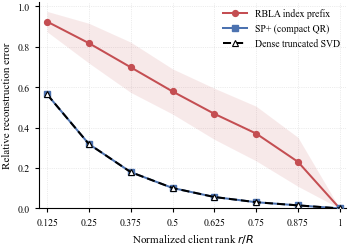

In [4]:
summary = (
    results.groupby(["method", "r", "normalized_rank"], as_index=False)
    ["relative_error"]
    .agg(["mean", "std"])
    .reset_index()
)

styles = {
    "RBLA index prefix": dict(color="#C44E52", marker="o", linestyle="-", zorder=2),
    "SP+ (compact QR)": dict(color="#4C72B0", marker="s", linestyle="-", zorder=3),
    "Dense truncated SVD": dict(
        color="black", marker="^", markerfacecolor="white",
        markeredgewidth=0.8, linestyle="--", dashes=(4, 2), zorder=4
    ),
}
method_order = ["RBLA index prefix", "SP+ (compact QR)", "Dense truncated SVD"]

fig, ax = plt.subplots(figsize=(3.5, 2.5))
for method in method_order:
    group = summary[summary["method"] == method].sort_values("normalized_rank")
    x = group["normalized_rank"].to_numpy()
    mean = group["mean"].to_numpy()
    std = group["std"].fillna(0.0).to_numpy()
    ax.fill_between(x, np.maximum(mean - std, 0.0), mean + std,
                    color=styles[method]["color"], alpha=0.12, linewidth=0, zorder=1)
    ax.plot(x, mean, label=method, **styles[method])

ax.set_xlabel(r"Normalized client rank $r/R$")
ax.set_ylabel("Relative reconstruction error")
ax.set_xlim(0.1, 1.02)
ax.set_ylim(bottom=0.0)
ax.set_xticks(RANKS / R)
ax.set_xticklabels([f"{r / R:.3g}" for r in RANKS])
ax.grid(True, which="major")
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(direction="out", width=0.8, length=3)
ax.legend(loc="upper right", handlelength=2.4, borderaxespad=0.3)
fig.tight_layout(pad=0.25)

for suffix, kwargs in (
    ("pdf", {}),
    ("svg", {}),
    ("png", {"dpi": 600}),
):
    fig.savefig(OUTPUT_DIR / f"broadcast_reconstruction_error.{suffix}", **kwargs)

plt.show()

In [5]:
mean_errors = results.groupby("method")["relative_error"].mean()
mean_by_rank = results.groupby(["r", "method"])["relative_error"].mean().unstack()
reductions = mean_by_rank["RBLA index prefix"] - mean_by_rank["SP+ (compact QR)"]
max_reduction_rank = int(reductions.idxmax())

print("Synthetic experiment summary")
print(f"  source: structured synthetic LoRA factors; checkpoint: N/A")
print(f"  shape: {D_OUT} x {D_IN}; R={R}; ranks={RANKS.tolist()}")
print(f"  factor rotations: {len(ROTATION_SEEDS)} seeds ({ROTATION_SEEDS[0]}-{ROTATION_SEEDS[-1]})")
print(f"  mean RBLA error: {mean_errors['RBLA index prefix']:.6e}")
print(f"  mean SP+ error: {mean_errors['SP+ (compact QR)']:.6e}")
print(f"  mean dense-SVD error: {mean_errors['Dense truncated SVD']:.6e}")
print(f"  maximum mean error reduction: {reductions.max():.6e} at r={max_reduction_rank}")
print(f"  maximum SP+/dense matrix difference: {max_matrix_difference:.6e}")
print(f"  maximum full-rank compact reconstruction error: "
      f"{diagnostics_df['full_reconstruction_error'].max():.6e}")
print(f"  all numerical checks passed: {all_checks_passed}")
print("  outputs:")
for path in sorted(OUTPUT_DIR.glob("broadcast_reconstruction_error.*")):
    print(f"    - {path.name}")

Synthetic experiment summary
  source: structured synthetic LoRA factors; checkpoint: N/A
  shape: 128 x 96; R=8; ranks=[1, 2, 3, 4, 5, 6, 7, 8]
  factor rotations: 20 seeds (42-61)
  mean RBLA error: 5.112656e-01
  mean SP+ error: 1.583435e-01
  mean dense-SVD error: 1.583435e-01
  maximum mean error reduction: 5.188587e-01 at r=3
  maximum SP+/dense matrix difference: 2.292947e-15
  maximum full-rank compact reconstruction error: 1.817763e-15
  all numerical checks passed: True
  outputs:
    - broadcast_reconstruction_error.csv
    - broadcast_reconstruction_error.pdf
    - broadcast_reconstruction_error.png
    - broadcast_reconstruction_error.svg
